**12주차 복습과제**

📍Swin Transformer: Hierarchical Vision Transformer using Shifted Windows

교재 :  <(파이토치 트랜스포머를 활용한) 자연어 처리와 컴퓨터 비전 심층학습>

범위 : 10장 Swin Transformer (p624~p643)

In [1]:
#상대적 위치 편향 계산
import torch

window_size = 2
coords_h = torch.arange(window_size)
coords_w = torch.arange(window_size)
coords = torch.stack(torch.meshgrid([coords_h, coords_w], indexing="ij"))
coords_flatten = torch.flatten(coords, 1)
relative_coords = coords_flatten[:, :, None] - coords_flatten[:, None, :]

print(relative_coords)
print(relative_coords.shape)

tensor([[[ 0,  0, -1, -1],
         [ 0,  0, -1, -1],
         [ 1,  1,  0,  0],
         [ 1,  1,  0,  0]],

        [[ 0, -1,  0, -1],
         [ 1,  0,  1,  0],
         [ 0, -1,  0, -1],
         [ 1,  0,  1,  0]]])
torch.Size([2, 4, 4])


In [2]:
#X, Y축에 대한 위치 행렬
x_coords = relative_coords[0, :, :]
y_coords = relative_coords[1, :, :]

x_coords += window_size - 1
y_coords += window_size - 1
x_coords *= 2 * window_size - 1
print(f"X축에 대한 행렬:\n{x_coords}\n")
print(f"Y축에 대한 행렬:\n{y_coords}\n")

relative_position_index= x_coords + y_coords
print(f"X, Y축에 대한 위치 행렬:\n{relative_position_index}")

X축에 대한 행렬:
tensor([[3, 3, 0, 0],
        [3, 3, 0, 0],
        [6, 6, 3, 3],
        [6, 6, 3, 3]])

Y축에 대한 행렬:
tensor([[1, 0, 1, 0],
        [2, 1, 2, 1],
        [1, 0, 1, 0],
        [2, 1, 2, 1]])

X, Y축에 대한 위치 행렬:
tensor([[4, 3, 1, 0],
        [5, 4, 2, 1],
        [7, 6, 4, 3],
        [8, 7, 5, 4]])


In [3]:
#X, Y축에 대한 상대적 위치 좌표 변환
num_heads = 1
relative_position_bias_table = torch. Tensor(
torch.zeros((2 * window_size -1) *(2 * window_size - 1), num_heads)
)

relative_position_bias = relative_position_bias_table[relative_position_index.view(-1)]
relative_position_bias = relative_position_bias.view(
    window_size * window_size, window_size * window_size, -1
)
print(relative_position_bias.shape)


torch.Size([4, 4, 1])


###모델 실습

In [4]:
#FashionMNIST 다운로드
from itertools import chain
from collections import defaultdict
from torch.utils.data import Subset
from torchvision import datasets

def subset_sampler(dataset, classes, max_len):
    target_idx = defaultdict(list)
    for idx, label in enumerate(dataset.train_labels):
        target_idx[int(label)].append(idx)

    indices = list(
        chain.from_iterable(
            [target_idx[idx][:max_len] for idx in range(len(classes))]
        )
    )
    return Subset(dataset, indices)

train_dataset = datasets. FashionMNIST(root=".. /datasets", download=True, train=True)
test_dataset = datasets. FashionMNIST(root=".. /datasets", download=True, train=False)

classes = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

print(classes)
print(class_to_idx)

subset_train_dataset = subset_sampler(
    dataset=train_dataset, classes=train_dataset.classes, max_len=1000

)
subset_test_dataset = subset_sampler(
    dataset=test_dataset, classes=test_dataset.classes, max_len=100
)

print(f"Training Data Size : {len(subset_train_dataset)}")
print(f"Testing Data Size : {len(subset_test_dataset)}")
print(train_dataset[0])

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 170kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.16MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 28.2MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")


['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
{'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}
Training Data Size : 10000
Testing Data Size : 1000
(<PIL.Image.Image image mode=L size=28x28 at 0x7BC6B47BF230>, 9)


In [6]:
#이미지 전처리
import torch
from torchvision import transforms
from transformers import AutoImageProcessor

image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path="microsoft/swin-tiny-patch4-window7-224"
)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize(
            size=(
                image_processor.size["height"],
                image_processor.size["width"]
                )
        ),

        transforms.Lambda(lambda x: torch.cat([x, x, x], 0)),
        transforms.Normalize(
            mean=image_processor.image_mean,
            std=image_processor.image_std
        )
    ]
)

print(f"size: {image_processor.size}")
print(f"mean:{image_processor.image_mean}")
print(f"std : {image_processor.image_std}")

size: {'height': 224, 'width': 224}
mean:[0.485, 0.456, 0.406]
std : [0.229, 0.224, 0.225]


In [7]:
#데이터로더 적용
from torch.utils.data import DataLoader

def collator(data, transform):
    images, labels = zip(*data)
    pixel_values = torch.stack([transform(image) for image in images])
    labels = torch. tensor([label for label in labels])
    return {"pixel_values": pixel_values, "labels": labels}

train_dataloader = DataLoader(
    subset_train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=lambda x: collator(x, transform),
    drop_last=True
)
valid_dataloader = DataLoader(
    subset_test_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=lambda x: collator(x, transform),
    drop_last=True
)
batch = next(iter(train_dataloader))
for key, value in batch.items():
    print(f"{key} : {value.shape}")

pixel_values : torch.Size([32, 3, 224, 224])
labels : torch.Size([32])


In [8]:
#사전학습된 스윈 트랜스포머 모델
from transformers import SwinForImageClassification

model = SwinForImageClassification.from_pretrained(
    pretrained_model_name_or_path="microsoft/swin-tiny-patch4-window7-224",
    num_labels=len(train_dataset.classes),
    id2label={idx: label for label, idx in train_dataset.class_to_idx.items()},
    label2id=train_dataset.class_to_idx,
    ignore_mismatched_sizes=True
)

for main_name, main_module in model.named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("L", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("| L", ssub_name)
            for sssub_name, sssub_module in ssub_module.named_children():
                if sssub_name == "projection":
                    print("| | L", sssub_name, sssub_module)
                else:
                    print("||L", sssub_name)

config.json:   0%|          | 0.00/71.8k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/233 [00:00<?, ?it/s]

SwinForImageClassification LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([10])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


swin
L embeddings
| L patch_embeddings
| | L projection Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
| L norm
| L dropout
L encoder
| L layers
||L 0
||L 1
||L 2
||L 3
L layernorm
L pooler
classifier


In [9]:
#패치 임베딩 모듈
batch = next(iter(train_dataloader))
print("이미지 차원 :", batch["pixel_values"].shape)

patch_emb_output, shape = model.swin.embeddings.patch_embeddings(batch["pixel_values"])
print("모듈:", model.swin.embeddings.patch_embeddings)
print("패치 임베딩 차원 :", patch_emb_output.shape)

이미지 차원 : torch.Size([32, 3, 224, 224])
모듈: SwinPatchEmbeddings(
  (projection): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
)
패치 임베딩 차원 : torch.Size([32, 3136, 96])


In [10]:
#스윈 트랜스포머 블록
for main_name, main_module in model.swin.encoder.layers[0].named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("L", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("|L", ssub_name)

blocks
L 0
|L layernorm_before
|L attention
|L drop_path
|L layernorm_after
|L intermediate
|L output
L 1
|L layernorm_before
|L attention
|L drop_path
|L layernorm_after
|L intermediate
|L output
downsample
L reduction
L norm


In [11]:
#SwinLayer 구조
print(model.swin.encoder.layers[0].blocks[0])

SwinLayer(
  (layernorm_before): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  (attention): SwinAttention(
    (self): SwinSelfAttention(
      (query): Linear(in_features=96, out_features=96, bias=True)
      (key): Linear(in_features=96, out_features=96, bias=True)
      (value): Linear(in_features=96, out_features=96, bias=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (output): SwinSelfOutput(
      (dense): Linear(in_features=96, out_features=96, bias=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
  )
  (drop_path): Identity()
  (layernorm_after): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  (intermediate): SwinIntermediate(
    (dense): Linear(in_features=96, out_features=384, bias=True)
    (intermediate_act_fn): GELUActivation()
  )
  (output): SwinOutput(
    (dense): Linear(in_features=384, out_features=96, bias=True)
    (dropout): Dropout(p=0.0, inplace=False)
  )
)


In [12]:
#W-MSA, SW-MSA 모듈
print("패치 임베딩 차원 :", patch_emb_output.shape)

W_MSA = model.swin.encoder.layers[0].blocks[0]
SW_MSA = model.swin.encoder.layers[0].blocks[1]

W_MSA_output = W_MSA(patch_emb_output, W_MSA.input_resolution)[0]
SW_MSA_output = SW_MSA(W_MSA_output, SW_MSA.input_resolution)[0]

print("W-MSA 결과 차원 :", W_MSA_output.shape)
print("SW-MSA 결과 차원 :", SW_MSA_output.shape)

패치 임베딩 차원 : torch.Size([32, 3136, 96])
W-MSA 결과 차원 : torch.Size([32, 3136, 96])
SW-MSA 결과 차원 : torch.Size([32, 3136, 96])


In [13]:
#패치 병합
patch_merge = model.swin.encoder.layers[0].downsample
print("patch_merge 모듈 :", patch_merge)

output = patch_merge(SW_MSA_output, patch_merge.input_resolution)
print("patch_merge 결과 차원 :", output.shape)

patch_merge 모듈 : SwinPatchMerging(
  (reduction): Linear(in_features=384, out_features=192, bias=False)
  (norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
)
patch_merge 결과 차원 : torch.Size([32, 784, 192])


In [15]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.2 MB/s eta 0:00:00


In [18]:
#스윈 트랜스포머 모델 학습
from transformers import SwinForImageClassification
import torch
import evaluate
import numpy as np
from itertools import chain
from collections import defaultdict
from torch.utils.data import Subset
from torchvision import datasets
from torchvision import transforms
from transformers import AutoImageProcessor
from transformers import TrainingArguments, Trainer

def subset_sampler(dataset, classes, max_len):
    target_idx = defaultdict(list)
    for idx, label in enumerate(dataset.train_labels):
        target_idx[int(label)].append(idx)

    indices = list(
        chain.from_iterable(
        [target_idx[idx][:max_len] for idx in range(len(classes))]
        )
    )
    return Subset(dataset, indices)

def model_init(classes, class_to_idx):
    model = SwinForImageClassification.from_pretrained(
        pretrained_model_name_or_path="microsoft/swin-tiny-patch4-window7-224",
        num_labels=len(classes),
        id2label={idx: label for label, idx in class_to_idx.items()},
        label2id=class_to_idx,
        ignore_mismatched_sizes=True
    )
    return model

def collator(data, transform):
    images, labels = zip(*data)
    pixel_values = torch.stack([transform(image) for image in images])
    labels = torch. tensor([label for label in labels])
    return {"pixel_values": pixel_values, "labels": labels}

def compute_metrics(eval_pred):
    metric = evaluate.load("f1")
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    macro_f1 = metric.compute(
        predictions=predictions, references=labels, average="macro"
    )
    return macro_f1

train_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=True)
test_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=False)

classes = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

subset_train_dataset = subset_sampler(
    dataset=train_dataset, classes=train_dataset.classes, max_len=1000
)
subset_test_dataset = subset_sampler(
    dataset=test_dataset, classes=test_dataset.classes, max_len=100
)

image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path="microsoft/swin-tiny-patch4-window7-224"
)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize(
            size=(
                image_processor.size["height"],
                image_processor.size["width"]
            )
        ),
        transforms.Lambda(lambda x: torch.cat([x, x, x], 0)),
        transforms.Normalize(
            mean=image_processor.image_mean,
            std=image_processor.image_std
        )
    ]
)

args = TrainingArguments(
    output_dir="../models/Swin-FashionMNIST",
    save_strategy="epoch",
    eval_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.001,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="logs",
    logging_steps=125,
    remove_unused_columns=False,
    seed=7
)

trainer = Trainer(
    model_init=lambda x: model_init(classes, class_to_idx),
    args=args,
    train_dataset=subset_train_dataset,
    eval_dataset=subset_test_dataset,
    data_collator=lambda x: collator(x, transform),
    compute_metrics=compute_metrics,
    #tokenizer=image_processor,
)
trainer.train()

/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Loading weights:   0%|          | 0/233 [00:00<?, ?it/s]

SwinForImageClassification LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([10])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Loading weights:   0%|          | 0/233 [00:00<?, ?it/s]

SwinForImageClassification LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([10])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Epoch,Training Loss,Validation Loss,F1
1,0.345540,0.294849,0.892420
2,0.244528,0.255835,0.906295
3,0.215379,0.226628,0.920261


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1875, training_loss=0.363397450764974, metrics={'train_runtime': 442.0168, 'train_samples_per_second': 67.871, 'train_steps_per_second': 4.242, 'total_flos': 7.4584635826176e+17, 'train_loss': 0.363397450764974, 'epoch': 3.0})

PredictionOutput(predictions=array([[ 8.309152  , -2.7967901 , -0.11402015, ..., -2.2127826 ,
        -1.6336255 , -2.1720495 ],
       [ 4.9001274 ,  0.04213408,  0.97175115, ..., -2.0664575 ,
        -0.9574591 , -2.8518763 ],
       [ 7.58434   , -3.106429  , -0.4614926 , ..., -1.2883755 ,
         0.29625595, -1.7633694 ],
       ...,
       [-1.0999469 , -3.1739292 , -2.272594  , ...,  1.2203808 ,
         0.9105788 ,  4.3097878 ],
       [-0.56345034, -3.2170541 , -1.7150015 , ...,  1.4285647 ,
        -2.82656   ,  9.035491  ],
       [-1.7972195 , -2.1229043 , -1.5342511 , ..., -1.1913375 ,
        -1.725353  ,  8.093446  ]], dtype=float32), label_ids=array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

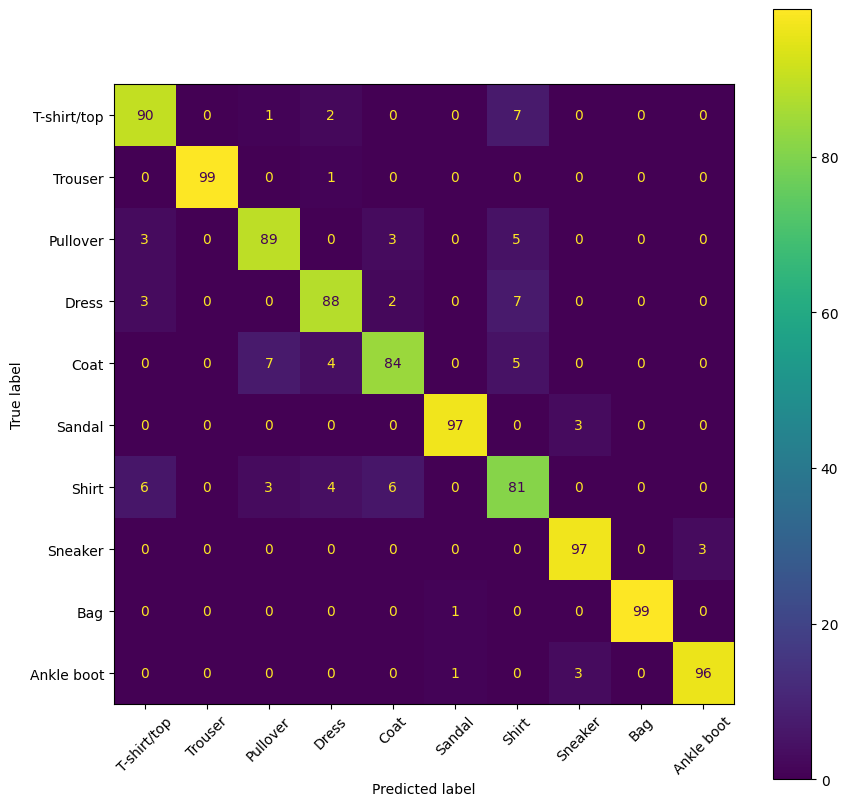

In [19]:
#스윈 트랜스포머 모델 성능 평가
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

outputs = trainer.predict(subset_test_dataset)
print(outputs)

y_true = outputs.label_ids
y_pred = outputs.predictions.argmax(1)

labels = list(classes)
matrix = confusion_matrix(y_true, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=labels)
_, ax = plt.subplots(figsize=(10, 10))
display.plot(xticks_rotation=45, ax=ax)
plt.show()